# EDA — Bank Credit Card Transactions (`creditcard.csv`)

**Project:** Improved Detection of Fraud Cases — Adey Innovations Inc.  
**Task:** Task 1 — Data Analysis and Preprocessing  
**Dataset:** `creditcard.csv`

---

## Objectives

1. Understand the structure of the PCA-anonymized credit card dataset.
2. Detect and handle missing values and duplicates.
3. Explore distributions of Amount, Time, and V1–V28 features.
4. Quantify the severe class imbalance (~0.17% fraud).
5. Apply feature engineering, encoding, scaling, and SMOTE.

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Imports & Configuration |
| 2 | Load Data |
| 3 | Data Cleaning |
| 4 | Exploratory Data Analysis |
| 5 | Class Imbalance Analysis |
| 6 | Feature Engineering |
| 7 | Encoding, Scaling & SMOTE |
| 8 | Save Processed Splits |

In [1]:
import logging
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s'
)
logger = logging.getLogger(__name__)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RAW_DIR       = '../data/raw/'
PROCESSED_DIR = '../data/processed/'

logger.info('Libraries loaded.')

2026-06-07 19:57:29,344 — INFO — Libraries loaded.


## 2. Load Data

Load creditcard.csv. Features V1–V28 are PCA-transformed for privacy.
Only Amount and Time retain their original scale.

In [2]:
try:
    cc_df = pd.read_csv(RAW_DIR + 'creditcard.csv')
    logger.info(f'creditcard.csv loaded: {cc_df.shape}')
except FileNotFoundError as e:
    logger.error(f'File not found: {e}')
    raise
except Exception as e:
    logger.error(f'Unexpected load error: {e}')
    raise

print('Shape:', cc_df.shape)
display(cc_df.head())
display(cc_df.describe())

2026-06-07 19:58:22,836 — INFO — creditcard.csv loaded: (284807, 31)


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Data Cleaning

- Missing values: inspect and report
- Duplicates: detect and remove
- Data types: verify all V columns are float, Class is integer

In [3]:
# Missing values
missing = cc_df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.any() else 'None found.')

# Duplicates
n_dup = cc_df.duplicated().sum()
logger.info(f'Duplicate rows: {n_dup}')
if n_dup > 0:
    cc_df.drop_duplicates(inplace=True)
    logger.info(f'Duplicates removed. New shape: {cc_df.shape}')

# Data types
try:
    cc_df['Class'] = cc_df['Class'].astype(int)
    logger.info('Class column cast to int.')
except Exception as e:
    logger.error(f'Type conversion failed: {e}')
    raise

print('\nUpdated dtypes (sample):')
print(cc_df.dtypes[['Time', 'Amount', 'Class']])

Missing values:
None found.


2026-06-07 19:58:39,387 — INFO — Duplicate rows: 1081
2026-06-07 19:58:42,451 — INFO — Duplicates removed. New shape: (283726, 31)
2026-06-07 19:58:42,455 — INFO — Class column cast to int.



Updated dtypes (sample):
Time      float64
Amount    float64
Class       int64
dtype: object


## 4. Exploratory Data Analysis

### 4.1 Distribution of Amount and Time

Amount and Time are the only non-anonymized features.
Amount is heavily right-skewed; Time reflects seconds since the first transaction.

### 4.2 PCA Feature Distributions (V1–V28)

V1–V28 are already centered and scaled from PCA. We check for any extreme
outliers that might indicate data quality issues.

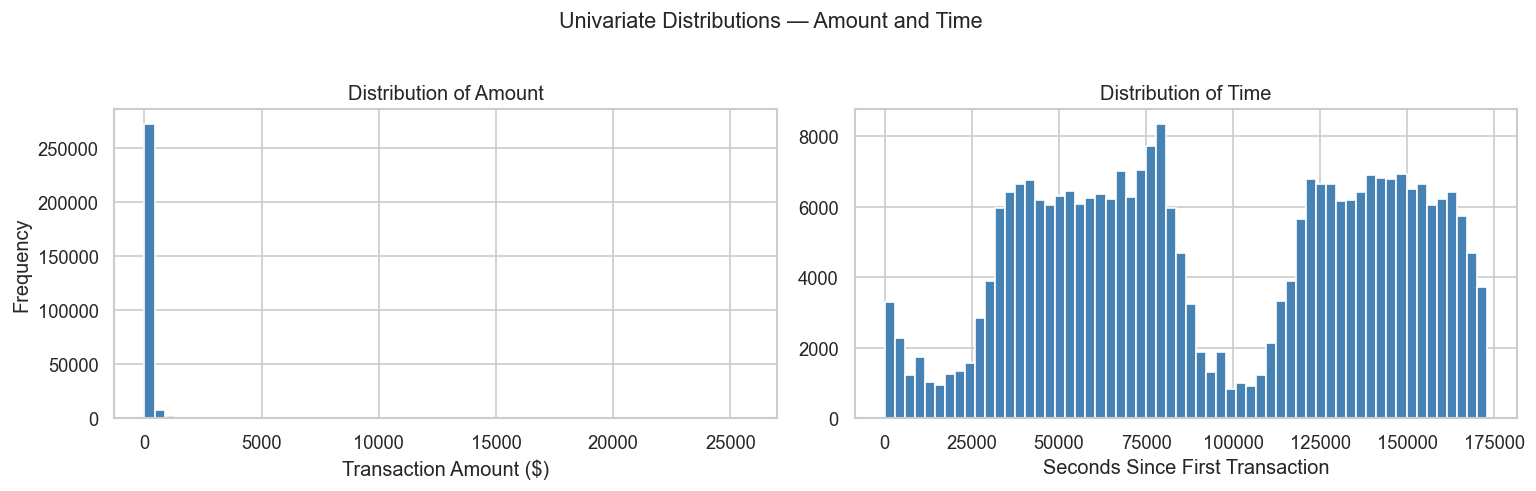

In [4]:
# Amount and Time distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cc_df['Amount'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Amount')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Frequency')

cc_df['Time'].hist(bins=60, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Time')
axes[1].set_xlabel('Seconds Since First Transaction')

plt.suptitle('Univariate Distributions — Amount and Time', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

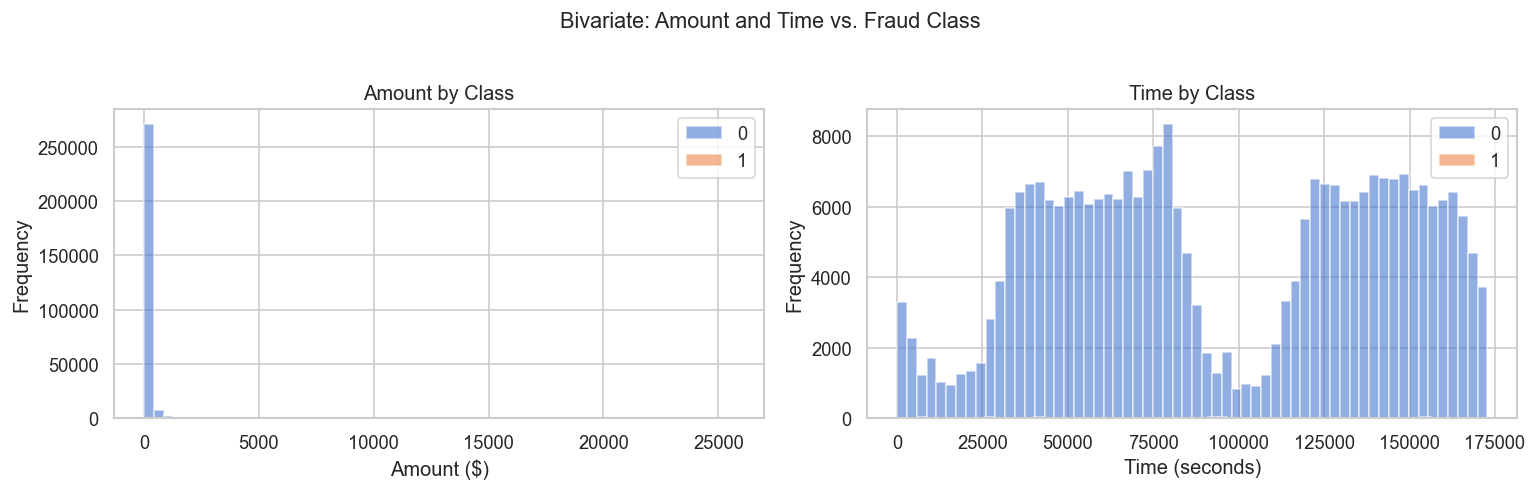

In [5]:
# Bivariate: Amount and Time by fraud class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cc_df.groupby('Class')['Amount'].plot(
    kind='hist', bins=60, alpha=0.6, ax=axes[0], legend=True
)
axes[0].set_title('Amount by Class')
axes[0].set_xlabel('Amount ($)')

cc_df.groupby('Class')['Time'].plot(
    kind='hist', bins=60, alpha=0.6, ax=axes[1], legend=True
)
axes[1].set_title('Time by Class')
axes[1].set_xlabel('Time (seconds)')

plt.suptitle('Bivariate: Amount and Time vs. Fraud Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

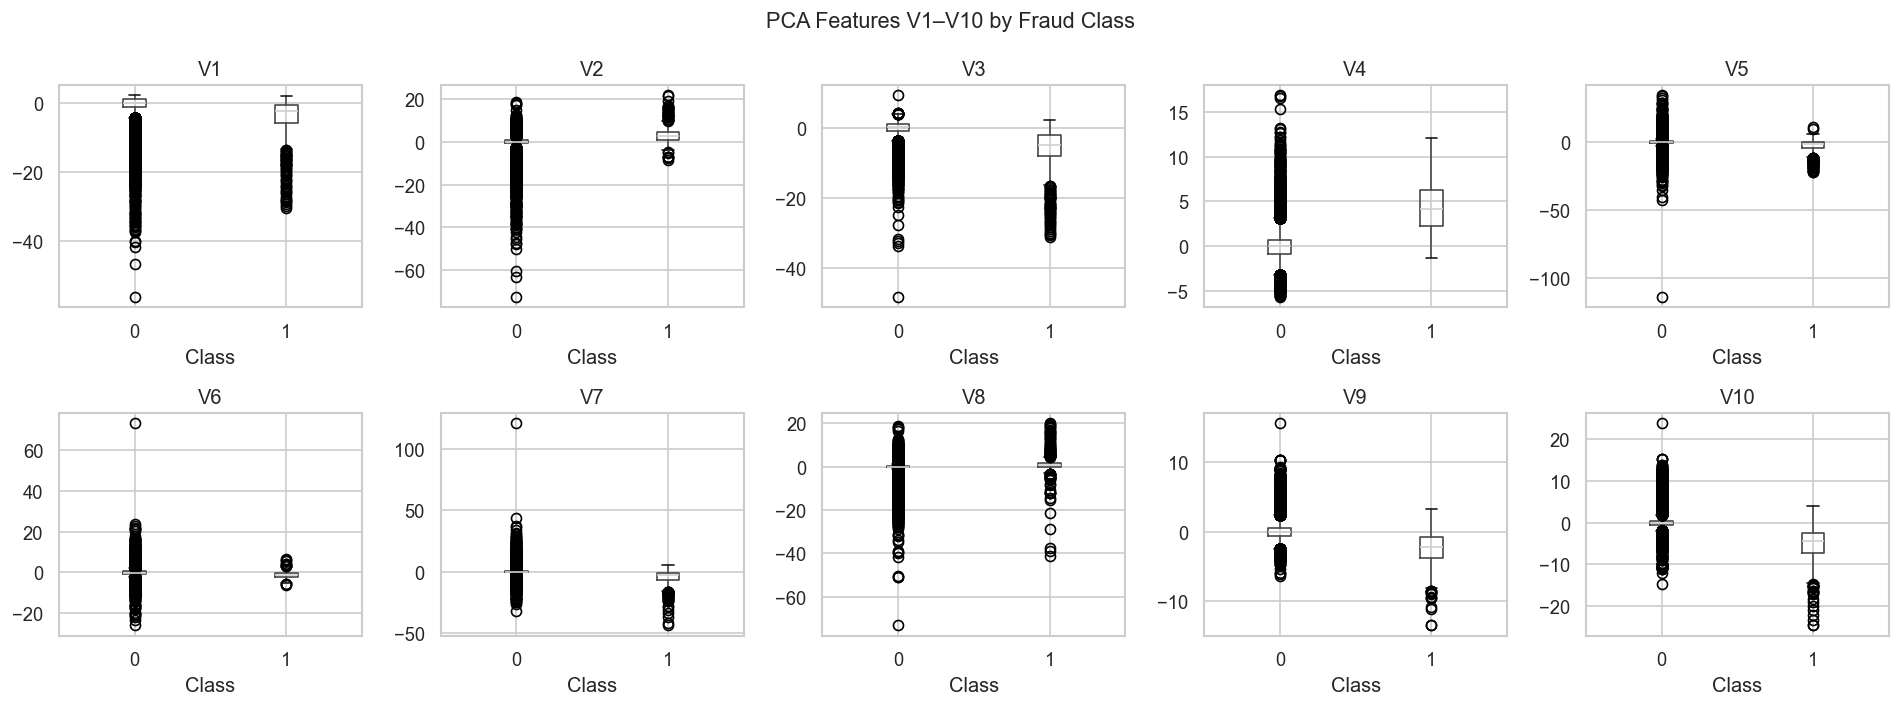

In [6]:
# Boxplots of top V features by class (V1–V10)
v_cols = [f'V{i}' for i in range(1, 11)]
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    cc_df.boxplot(column=col, by='Class', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Class')

plt.suptitle('PCA Features V1–V10 by Fraud Class', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Class Imbalance Analysis

The credit card dataset is far more severely imbalanced than Fraud_Data.csv.
With only 492 fraud cases out of 284,807 total transactions (~0.17%), a
naive classifier achieves 99.83% accuracy while missing all fraud — making
accuracy completely meaningless here. SMOTE is critical for this dataset.

Class Distribution:
        count  percentage
Class                    
0      283253     99.8333
1         473      0.1667

Imbalance ratio: 598:1


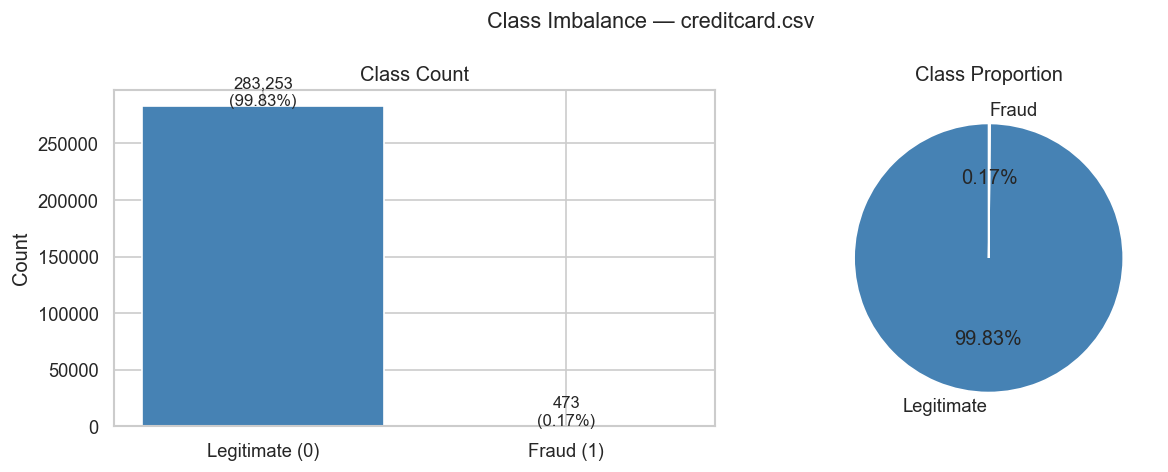

In [7]:
cc_counts = cc_df['Class'].value_counts()
cc_pct = cc_df['Class'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(pd.DataFrame({'count': cc_counts, 'percentage': cc_pct.round(4)}))
print(f'\nImbalance ratio: {cc_counts[0] // cc_counts[1]}:1')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], cc_counts.values,
             color=['steelblue', 'crimson'], edgecolor='white')
for i, v in enumerate(cc_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({cc_pct.values[i]:.2f}%)',
                 ha='center', fontsize=10)
axes[0].set_title('Class Count')
axes[0].set_ylabel('Count')

axes[1].pie(cc_counts.values, labels=['Legitimate', 'Fraud'],
             colors=['steelblue', 'crimson'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Class Proportion')

plt.suptitle('Class Imbalance — creditcard.csv', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

Amount is log-transformed to reduce right skew before scaling.
Time is converted to hour-of-day to capture cyclic transaction patterns.
V1–V28 are already PCA-transformed and require no further engineering.

In [8]:
try:
    # Log-transform Amount to reduce right skew
    cc_df['Amount_log'] = np.log1p(cc_df['Amount'])

    # Hour of day from Time (seconds elapsed — cyclic feature)
    cc_df['hour_of_day'] = (cc_df['Time'] // 3600) % 24

    logger.info('Feature engineering complete: Amount_log, hour_of_day added.')
    print(cc_df[['Amount', 'Amount_log', 'Time', 'hour_of_day']].head())
except Exception as e:
    logger.error(f'Feature engineering failed: {e}')
    raise

2026-06-07 19:59:58,671 — INFO — Feature engineering complete: Amount_log, hour_of_day added.


   Amount  Amount_log  Time  hour_of_day
0  149.62    5.014760   0.0          0.0
1    2.69    1.305626   0.0          0.0
2  378.66    5.939276   1.0          0.0
3  123.50    4.824306   1.0          0.0
4   69.99    4.262539   2.0          0.0


## 7. Encoding, Scaling, and SMOTE

No categorical features exist in creditcard.csv (all are numeric or PCA).
StandardScaler is applied to Amount_log and hour_of_day only — V1–V28 are
already scaled from PCA. SMOTE is applied on the training split only.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Drop original Amount and Time (replaced by engineered features)
cc_model = cc_df.drop(columns=['Amount', 'Time'])

X = cc_model.drop('Class', axis=1)
y = cc_model['Class']

# Stratified split
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    logger.info(f'Train: {X_train.shape} | Test: {X_test.shape}')
    logger.info(f'Train fraud rate: {y_train.mean():.4f}')
except Exception as e:
    logger.error(f'Split failed: {e}')
    raise

# Scale Amount_log and hour_of_day — fit on train only
try:
    scaler_cc = StandardScaler()
    scale_cols = ['Amount_log', 'hour_of_day']
    X_train[scale_cols] = scaler_cc.fit_transform(X_train[scale_cols])
    X_test[scale_cols]  = scaler_cc.transform(X_test[scale_cols])
    logger.info(f'Scaling applied to: {scale_cols}')
except Exception as e:
    logger.error(f'Scaling failed: {e}')
    raise

# SMOTE on training set only
try:
    print(f'Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}')
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f'After SMOTE:  {pd.Series(y_train_res).value_counts().to_dict()}')
    logger.info(f'Resampled training shape: {X_train_res.shape}')
except Exception as e:
    logger.error(f'SMOTE failed: {e}')
    raise

2026-06-07 20:00:17,992 — INFO — Train: (226980, 30) | Test: (56746, 30)
2026-06-07 20:00:17,995 — INFO — Train fraud rate: 0.0017
2026-06-07 20:00:18,033 — INFO — Scaling applied to: ['Amount_log', 'hour_of_day']


Before SMOTE: {0: 226602, 1: 378}
